In [1]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:

connection = sql.connect(r"D:\churn analyisi\customer_churn.db")  # ya C drive path

sql_query=("""SELECT name
 FROM sqlite_master
   WHERE type='table';""")


tables = pd.read_sql(sql_query, connection)

# create a dataframe for each table 
for table_name in tables['name']:

    df = pd.read_sql(f"SELECT * FROM {table_name};", connection)
    globals()[f"df_{table_name}"] = df
    print(f"create dataframe:df_{table_name}")   # first 5 rows
  



create dataframe:df_db_customer
create dataframe:df_db_subscription
create dataframe:df_db_support


In [3]:
connection = sql.connect(r"D:\churn analyisi\customer_churn.db")
for table_name in tables['name']:
    print(f"\n\nTable: {table_name}")
    # get column names and data types
    column_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(column_query, connection)
    print(columns)
    print(columns['name'].tolist())
connection.close()



Table: db_customer
   cid        name       type  notnull dflt_value  pk
0    0  customerid       TEXT        0       None   0
1    1        name       TEXT        0       None   0
2    2     country       TEXT        0       None   0
3    3       state       TEXT        0       None   0
4    4      gender       TEXT        0       None   0
5    5         dob  TIMESTAMP        0       None   0
6    6   interests       TEXT        0       None   0
7    7     pincode       REAL        0       None   0
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']


Table: db_subscription
    cid                     name     type  notnull dflt_value  pk
0     0               customerid     TEXT        0       None   0
1     1  subscription_start_date     TEXT        0       None   0
2     2        subscription_type     TEXT        0       None   0
3     3             renewal_date     TEXT        0       None   0
4     4                plan_type     TEXT        0    

In [4]:
print("\n\nDataframe information:")
print(df_db_customer.head(5))
print(df_db_customer.tail(5))
print(df_db_customer.info())




Dataframe information:
   customerid    name country        state  gender                  dob  \
0  0002-ORFBO  keshav   India  Maharashtra    Male  1982-04-12 00:00:00   
1  0003-MKNFE  raghav   India    Karnataka    Male  1995-11-23 00:00:00   
2  0004-TLHLJ  lalita   India        Delhi  Female  1978-02-15 00:00:00   
3  0011-IGKFF   mohan   India     Nagaland    Male  2001-08-30 00:00:00   
4  0013-EXCHZ    mira   India        Delhi  Female  1990-05-05 00:00:00   

  interests pincode  
0    travel    None  
1       NaN    None  
2     movie    None  
3       NaN    None  
4     drama    None  
    customerid        name country          state  gender  \
16  0020-JDNXP       rikim   India      Meghalaya  Female   
17  0021-IKXGC    vishakha   India      Rajasthan  Female   
18  0022-TCJCI  raghvendra   India      Telangana    Male   
19  0023-HGHWL     rishabh   India  Uttar Pradesh     Men   
20  0023-UYUPN      sudevi   India    Maharashtra   Women   

                    dob i

In [5]:
# data cleaning

In [6]:
df_db_customer.head(5)

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [7]:


df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [8]:
# drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [9]:
# change the data  types
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [10]:
# date standardization gender
# df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})


In [11]:
# fix the missing value
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [12]:
# change the data types - primary key
df_db_customer.set_index('customerid', inplace=True)

In [13]:
df_db_customer.reset_index(inplace=True)

In [14]:
df_db_customer.loc[df_db_customer['state'] == 'Kathmandu', 'country'] = 'Nepal'


In [15]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [16]:
date_col =['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [17]:
print(df_db_support.head(5))
df_db_support.info()

   customerid       complaint_date escalations  csat_score col_1  \
0  0003-MKNFE  2024-08-28 00:00:00           N          60  None   
1  0003-MKNFE  2024-08-28 00:00:00           Y          10  None   
2  0013-EXCHZ  2024-01-20 00:00:00           Y          20  None   
3  0013-MHZWF  2025-03-18 00:00:00           N          90  None   
4  0013-SMEOE  2024-11-01 00:00:00           N          30  None   

             comment  
0      service issue  
1     demaned refund  
2                NaN  
3  guidance to renew  
4                NaN  
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int6

In [18]:
# drop the column in df_db_support table - col_1 and comment
df_db_support.drop(columns=['col_1','comment'], inplace= True)
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [19]:
df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(pd.to_datetime)

In [20]:
#  feature engineering and data analysis

In [21]:
# create a new culomns

df_db_subscription['churn_flag']= np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [22]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


In [27]:
df= (df_db_subscription
    .merge(df_db_customer, on ='customerid', how = 'left')
    .merge(df_db_support, on ='customerid', how = 'left'))

In [28]:
# This section creates a column (complaint_count)
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [29]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep= 'last')

In [30]:
df_db_support['complaint_count']

2    1
5    1
1    1
8    1
6    1
4    1
3    1
Name: complaint_count, dtype: int64

In [31]:
df.shape

(21, 21)

In [32]:
df.to_csv('churn_data.csv', index=False)

In [33]:
# churn rate calculation

churn_rate= df['churn_flag'].mean()*100
print("churn_rate = ",round(churn_rate,2),"%")

churn_rate =  28.57 %


In [34]:
# retention rate
retention_rate = 100 - churn_rate
print("retention_rate",round(retention_rate,2),"%")




retention_rate 71.43 %


In [35]:
# churn by plan type
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean()*100
print(round(churn_by_plan,2))

plan_type
Basic       60.00
Premium     14.29
Standard    22.22
Name: churn_flag, dtype: float64


In [36]:
# homework
# a churn by state + sun(revenue) & count of user
churn_by_state = df.groupby('state').agg(
    churn_rate=('churn_flag', 'mean'),
    total_revenue=('monthly_charges', 'sum'),
    total_users=('customerid', 'count')
)

# churn rate ko percentage mein convert karo
churn_by_state['churn_rate'] = churn_by_state['churn_rate'] * 100

print(round(churn_by_state, 2))


               churn_rate  total_revenue  total_users
state                                                
Delhi               25.00          52.96            4
Karnataka          100.00          20.98            2
Kathmandu            0.00          20.98            2
Maharashtra          0.00          50.97            3
Meghalaya           66.67          42.97            3
Nagaland             0.00          22.99            1
Rajasthan            0.00          36.98            2
Telangana           50.00          30.98            2
Uttar Pradesh        0.00         115.98            2


In [37]:
# churn by subscription type
churn_by_sub= df.groupby('subscription_type')['churn_flag'].mean()*100
print(round(churn_by_sub,2))

subscription_type
Organic      0.00
Paid        16.67
Refferal    83.33
Name: churn_flag, dtype: float64


In [38]:
# ARPU Avg Revenue Par User
ARPU=df['monthly_charges'].mean().round(2)
print(f"ARPU: {ARPU}%")

ARPU: 18.85%


In [39]:
#  Avg Customer tenure
# count of days user has used service : cancellation date, else current date
today = pd.Timestamp.today()
df['Tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today  -df['subscription_start_date']).dt.days
)     
     
Avg_tenure= df['Tenure_days'].mean() 
print("Avg_tenure: -",round(Avg_tenure),"days")






Avg_tenure: - 1537 days


In [40]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'Tenure_days'],
      dtype='str')

In [41]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,Tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2006.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0


In [42]:
# Revenue at risk - revenue lost from churned users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at risk(Rs k)",revenue_at_risk)

Revenue at risk(Rs k) 73.94


In [43]:
# escalation Rate
escalations_rate= (df['escalations']=='Y').mean()*100
print("escalations_rate",round(escalations_rate,2),"%")


escalations_rate 19.05 %


In [44]:
# Avg complaints per user
avg_complain =df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg complain par user =", round(avg_complain,2))


Avg complain par user = 0.43


In [45]:
#  correlation escalation vs churn
corr_df =df[['escalations','churn_flag']].dropna()
df['escalations'] = np.where(df['escalations']== 'Y',1,0)

In [46]:
corr_df

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [47]:
corr_df = df[['escalations','churn_flag']].dropna()

In [48]:
# correlation
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("correlation escalation vs churn",round(correlation,2))

correlation escalation vs churn 0.77


In [49]:
# churn risk - create a column using existing col  
conditions= [

      (df['churn_score']<50),
      (df['churn_score']>= 50) & (df['churn_score']< 70),
      (df['churn_score']>= 70)    
]
choices = ['low', 'med', 'high']

df['churn_risk']= np.select(conditions,choices,default='unknow')





In [50]:
# visualisation using matplotlib


In [51]:
df_visual = df.copy()

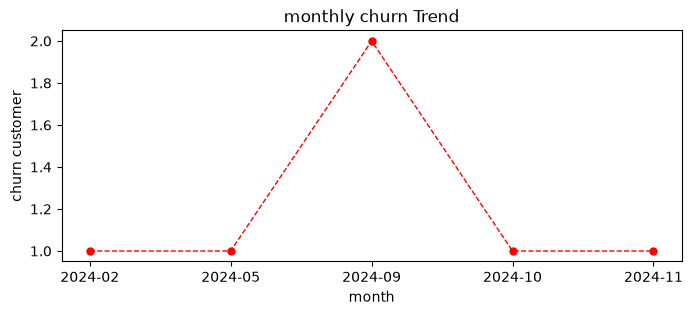

In [52]:
#  4.1 monthly churn trend
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='red', 
linestyle='--', linewidth=1, marker='o', markersize=5, label='Sales')
plt.title('monthly churn Trend')
plt.xlabel('month')
plt.ylabel('churn customer')
plt.show()

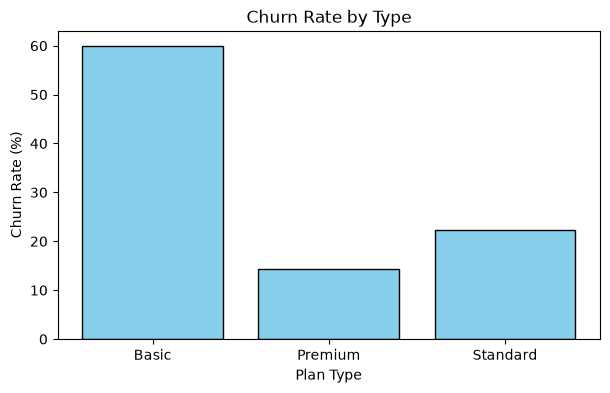

In [53]:
# 4.2 Churn by plan type
churn_by_plan = df_visual.groupby('plan_type')['churn_flag'].mean()*100
plt.figure(figsize=(7,4))

plt.bar(churn_by_plan.index, churn_by_plan.values,color='skyblue',
    edgecolor='black')
plt.title('Churn Rate by Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')

plt.show()


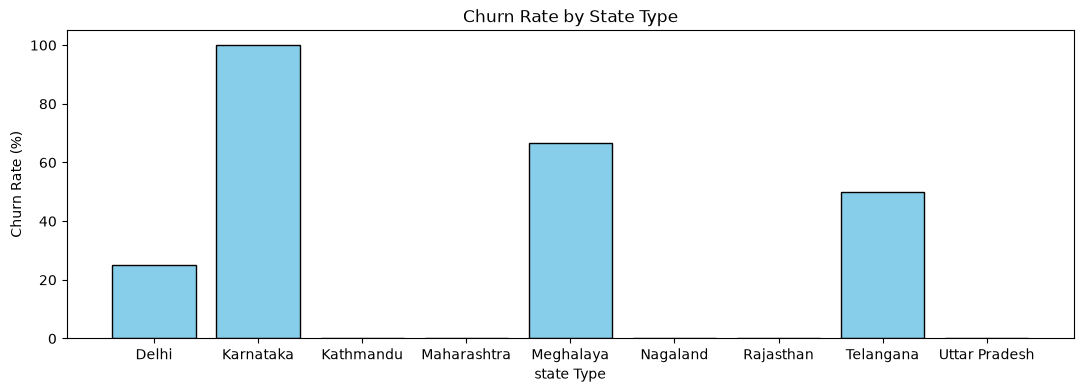

In [54]:
# 4.3 churn by state
churn_by_state = df_visual.groupby('state')['churn_flag'].mean()*100
plt.figure(figsize=(13,4))

plt.bar(churn_by_state.index, churn_by_state.values,color='skyblue',
    edgecolor='black')
plt.title('Churn Rate by State Type')
plt.xlabel('state Type')
plt.ylabel('Churn Rate (%)')

plt.show()

(array([  0.,  20.,  40.,  60.,  80., 100., 120.]),
 [Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120')])

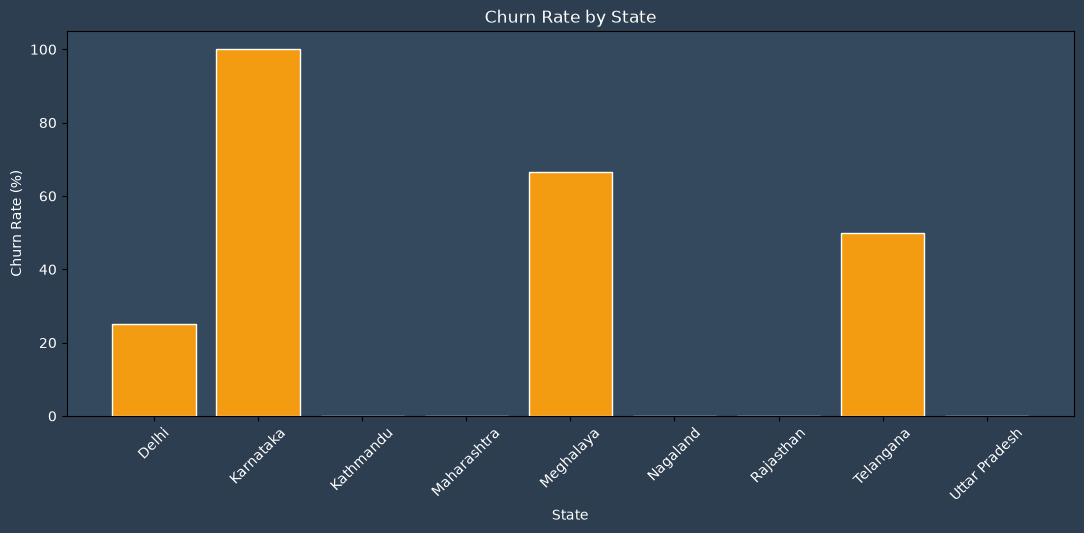

In [57]:
plt.figure(figsize=(13,5), facecolor='#2c3e50')
ax = plt.gca()
ax.set_facecolor('#34495e')

plt.bar(
    churn_by_state.index,
    churn_by_state.values,
    color='#f39c12',
    edgecolor='white'
)

plt.title('Churn Rate by State', color='white')
plt.xlabel('State', color='white')
plt.ylabel('Churn Rate (%)', color='white')
plt.xticks(color='white', rotation=45)
plt.yticks(color='white')

In [60]:
# visulaization using seaborn


In [ ]:
# encoding - convert str to numeric  so that we can find carr between feature

In [63]:
# incorrect of encoding - os number are not assigned based on pariority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag','churn_risk','escalations' ]].head(5)

category_col  = ['plan_type', 'contract_type','churn_risk']
 
for col in category_col:
    df_encoded[col] =  df_encoded[col].astype('category').cat.codes



<Axes: >

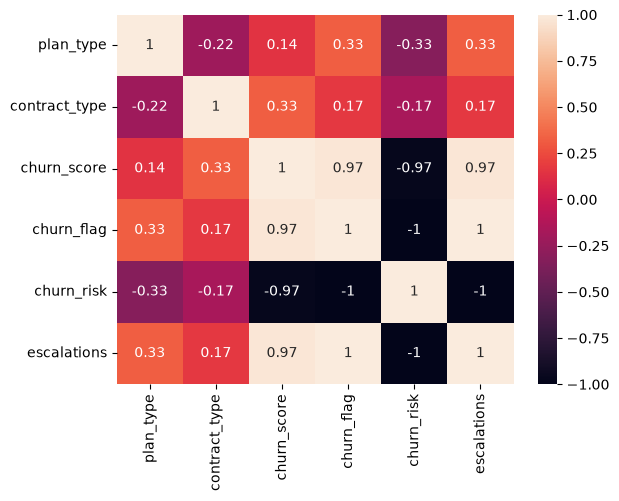

In [65]:
#  Hratmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot =True)

<Axes: >

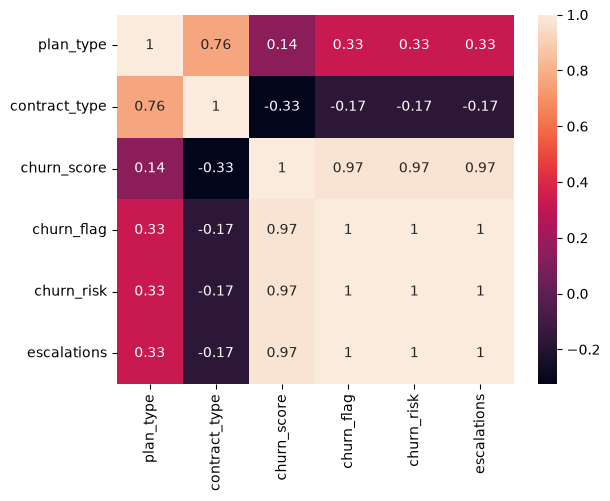

In [72]:
#  Hratmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot =True)

In [68]:
df_encoded

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [73]:
df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'churn_risk', 'escalations']
].head(5)

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

print(df_encoded)

   plan_type  contract_type  churn_score  churn_flag  churn_risk  escalations
0          1              1           12           0           0            0
1          2              1           91           1           2            1
2          0              0           34           0           0            0
3          2              1            8           0           0            0
4          1              0           88           1           2            1


<Axes: >

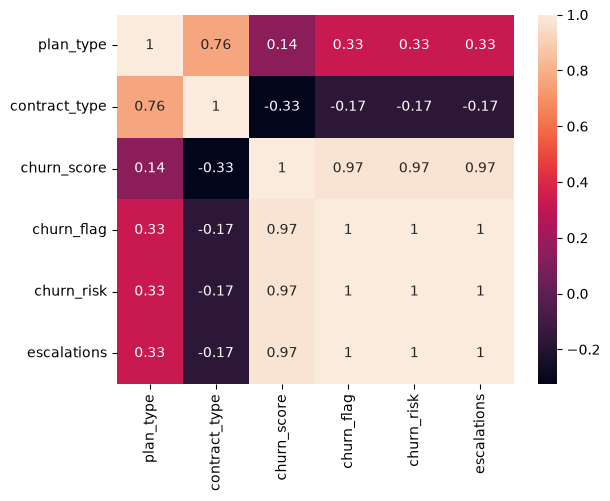

In [74]:
#  Hratmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot =True)

In [75]:
#  Hratmap(correlation matrix)
df_encoded

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


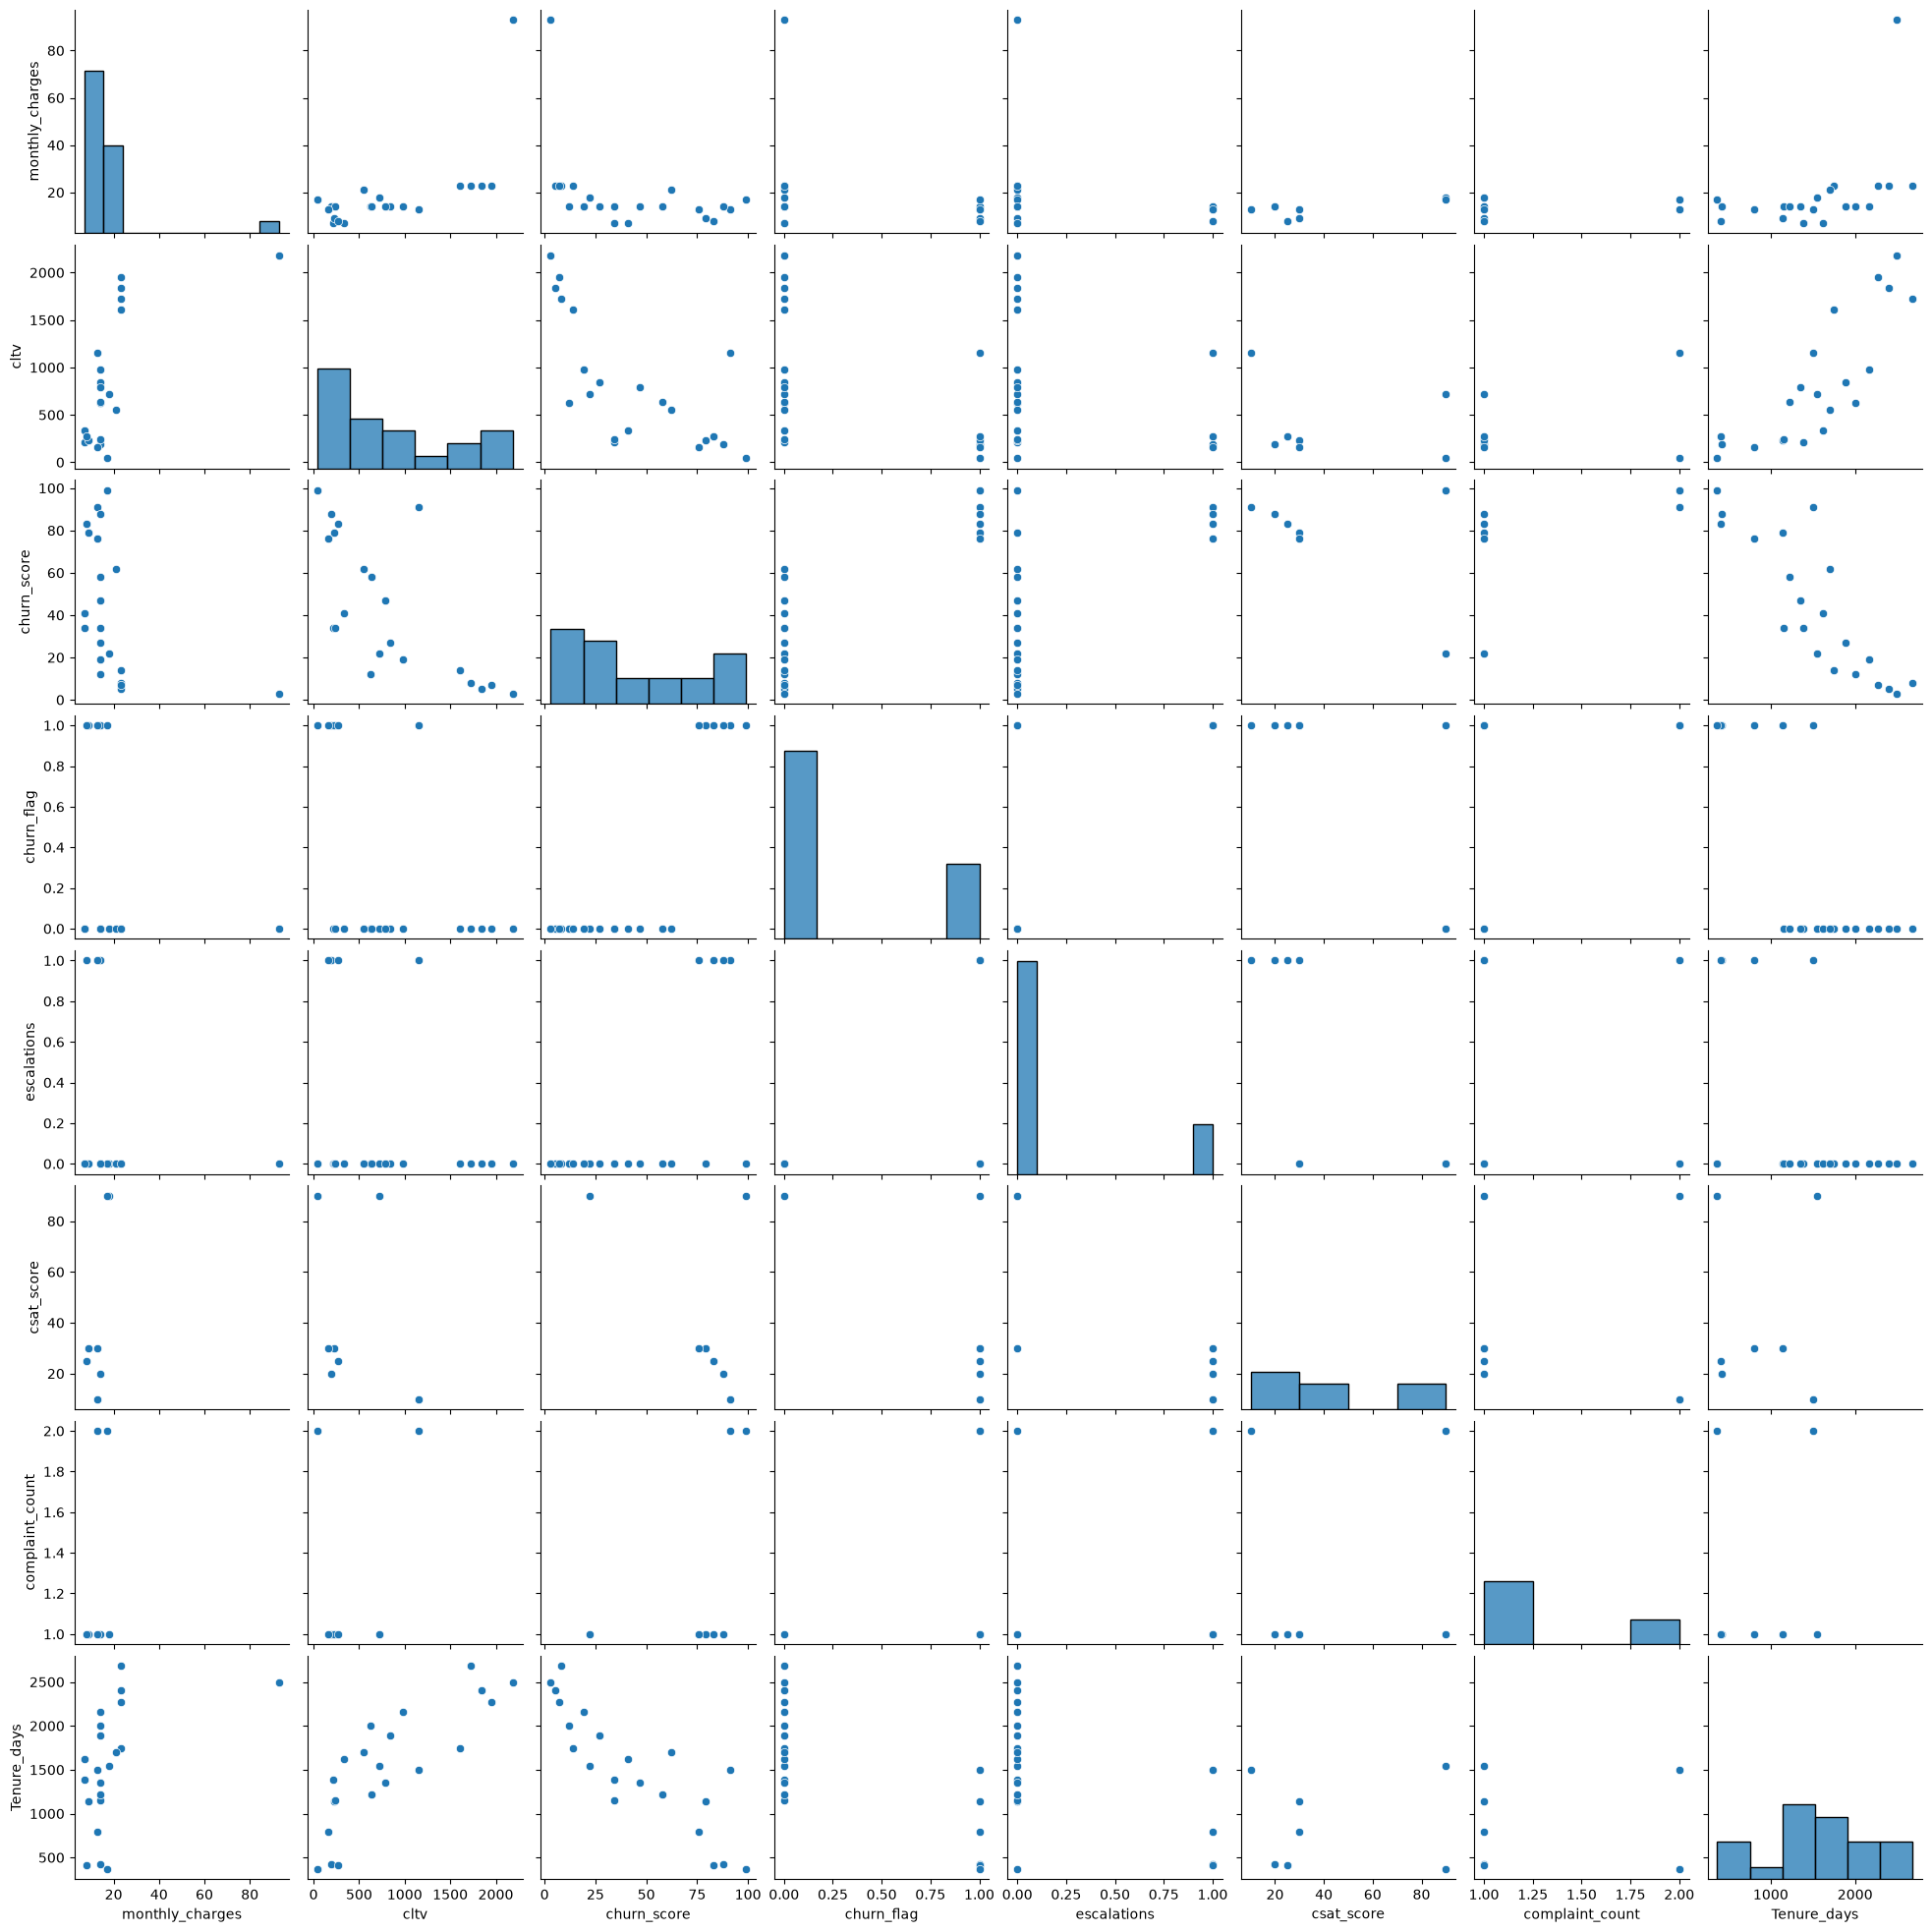

In [80]:
# pairplot
sns.pairplot(df_visual)

In [83]:
# pivot table
pd.pivot_table(
    df_visual ,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean',
    ).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [85]:
pd.pivot_table(
    df_visual ,
    index='plan_type',
    values =['monthly_charges','customerid','churn_flag'],
    aggfunc={'monthly_charges':'sum',
             'customerid': 'nunique',
             'churn_flag': 'mean'
            }

    )

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [81]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'Tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [ ]:
# SQL- working with sql in python (Panda)

In [90]:
# crete db in sql
conn = sql.connect('test_datebase.sqlite')
# table datails
conn.execute("create table user (first_name text,country text, budget integer )")

# commite and save
conn.commit()